In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

### Data prep

In [6]:
spam = pd.read_csv("..\spam_results.csv")
elec = pd.read_csv("..\electricity_results.csv")
college = pd.read_csv("..\college_results.csv")
employee = pd.read_csv("..\employee_results.csv")

In [7]:
df = pd.concat([spam, elec, college, employee], ignore_index=True)
df = df.drop('Unnamed: 0', axis=1)
print(df.head())

      method dataset missing_schema  accuracy  balanced_accuracy  f1_score  \
0     Oracle    Spam           MCAR  0.914224           0.907551  0.889510   
1      Naive    Spam           MCAR  0.919653           0.913956  0.896936   
2   KNN_hard    Spam           MCAR  0.912052           0.904314  0.886076   
3  KNN_proba    Spam           MCAR  0.915309           0.907003  0.889831   
4         EM    Spam           MCAR  0.920738           0.914852  0.898187   

    roc_auc  missing_rate  fold  n_neighbors  
0  0.966053           0.1     0          NaN  
1  0.967075           0.1     0          NaN  
2  0.966068           0.1     0          5.0  
3  0.965975           0.1     0          5.0  
4  0.966883           0.1     0          NaN  


In [92]:
summary = df.groupby(["dataset", "method", "missing_schema", "missing_rate"]).agg({
    "accuracy": "mean",
    "balanced_accuracy": "mean",
    "f1_score": "mean",
    "roc_auc": "mean"
}).reset_index()

print(summary)

     dataset  method missing_schema  missing_rate  accuracy  \
0    College      EM           MAR1           0.1  0.930388   
1    College      EM           MAR1           0.3  0.928303   
2    College      EM           MAR1           0.5  0.926057   
3    College      EM           MAR1           0.8  0.901995   
4    College      EM           MAR2           0.1  0.929746   
..       ...     ...            ...           ...       ...   
315     Spam  Oracle           MCAR           0.8  0.920019   
316     Spam  Oracle           MNAR           0.1  0.920019   
317     Spam  Oracle           MNAR           0.3  0.920019   
318     Spam  Oracle           MNAR           0.5  0.920019   
319     Spam  Oracle           MNAR           0.8  0.920019   

     balanced_accuracy  f1_score   roc_auc  
0             0.808670  0.702447  0.957191  
1             0.806401  0.695553  0.956079  
2             0.788735  0.675619  0.951705  
3             0.667546  0.442023  0.837106  
4             0.81

### Baseline results

In [93]:
oracle_results = summary.groupby(["method", "dataset"]).agg({
    "accuracy": "mean",
    "balanced_accuracy": "mean",
    "f1_score": "mean",
    "roc_auc": "mean"
}).reset_index()
oracle_results = oracle_results[oracle_results["method"] == "Oracle"]
print(oracle_results)

    method      dataset  accuracy  balanced_accuracy  f1_score   roc_auc
16  Oracle      College  0.930388           0.812966  0.705820  0.957384
17  Oracle  Electricity  0.755583           0.735427  0.676444  0.818916
18  Oracle     Employee  0.985661           0.500000  0.992779  0.686068
19  Oracle         Spam  0.920019           0.912191  0.896017  0.969251


In [94]:
methods_results = summary.groupby(["method", "missing_schema", "missing_rate"]).agg({
    "accuracy": "mean",
    "balanced_accuracy": "mean",
    "f1_score": "mean",
    "roc_auc": "mean"
}).reset_index()

print(methods_results)

    method missing_schema  missing_rate  accuracy  balanced_accuracy  \
0       EM           MAR1           0.1  0.897352           0.738271   
1       EM           MAR1           0.3  0.894571           0.735295   
2       EM           MAR1           0.5  0.892149           0.728418   
3       EM           MAR1           0.8  0.863189           0.667841   
4       EM           MAR2           0.1  0.898306           0.740136   
..     ...            ...           ...       ...                ...   
75  Oracle           MCAR           0.8  0.897913           0.740146   
76  Oracle           MNAR           0.1  0.897913           0.740146   
77  Oracle           MNAR           0.3  0.897913           0.740146   
78  Oracle           MNAR           0.5  0.897913           0.740146   
79  Oracle           MNAR           0.8  0.897913           0.740146   

    f1_score   roc_auc  
0   0.815973  0.857413  
1   0.811362  0.852978  
2   0.803677  0.850846  
3   0.668190  0.802925  
4   0.8175

### The employee dataset is excluded from further analyses
The employee dataset is extremely unbalanced, with 33958 instances of class 1 and 494 instances of class 0. For all experiments conducted for this dataset, the balanced accuracy value is equal to 0.5 (or 0.499926 in one case), while the accuracy metric is almost 1. This shows that in all experiments on this dataset, the produced model was only predicting the majority class. Thefore all examined approached did not handle this extremely unbalanced problem.

In [95]:
summary[summary["dataset"] == "Employee"]["balanced_accuracy"].value_counts()

0.500000    79
0.499985     1
Name: balanced_accuracy, dtype: int64

### Analyses of the remaining datasets

    method missing_schema  missing_rate  accuracy  balanced_accuracy  \
0       EM           MAR1           0.1  0.867915           0.817695   
1       EM           MAR1           0.3  0.864207           0.813727   
2       EM           MAR1           0.5  0.860979           0.804558   
3       EM           MAR1           0.8  0.822365           0.723788   
4       EM           MAR2           0.1  0.869188           0.820181   
..     ...            ...           ...       ...                ...   
75  Oracle           MCAR           0.8  0.868663           0.820195   
76  Oracle           MNAR           0.1  0.868663           0.820195   
77  Oracle           MNAR           0.3  0.868663           0.820195   
78  Oracle           MNAR           0.5  0.868663           0.820195   
79  Oracle           MNAR           0.8  0.868663           0.820195   

    f1_score   roc_auc  
0   0.757037  0.914572  
1   0.750889  0.913383  
2   0.740643  0.910824  
3   0.559994  0.846986  
4   0.7592

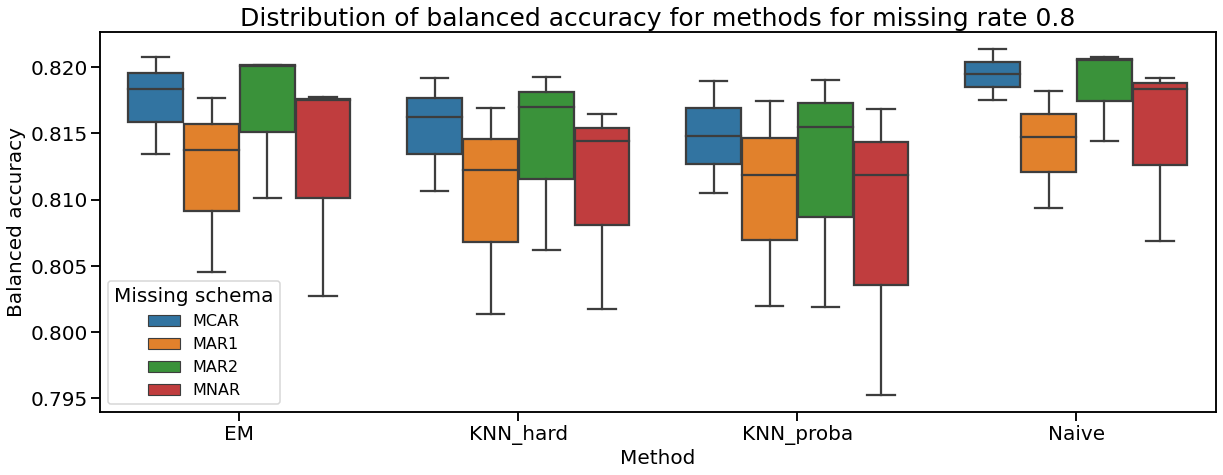

In [125]:
datasets_results = summary[summary["dataset"] != "Employee"].groupby(["method", "missing_schema", "missing_rate"]).agg({
    "accuracy": "mean",
    "balanced_accuracy": "mean",
    "f1_score": "mean",
    "roc_auc": "mean"
}).reset_index()


print(datasets_results)

plt.figure(figsize=(20,7))

ax = sns.boxplot(
    data=datasets_results[
        (datasets_results["missing_rate"] != 0.8) &
        (datasets_results["method"] != "Oracle")
    ],
    x="method",
    y="balanced_accuracy",
    hue="missing_schema",
    hue_order=["MCAR", "MAR1", "MAR2", "MNAR"]
)

ax.set_title("Distribution of balanced accuracy for methods for missing rate 0.8", fontsize=25)
ax.set_xlabel("Method", fontsize=20)
ax.set_ylabel("Balanced accuracy", fontsize=20)

ax.tick_params(axis='x', labelsize=20)
ax.tick_params(axis='y', labelsize=20)

plt.legend(title="Missing schema", fontsize=16, title_fontsize=20)

plt.show()

### Heatmaps of metrics for different datasets, missing schemas and rates

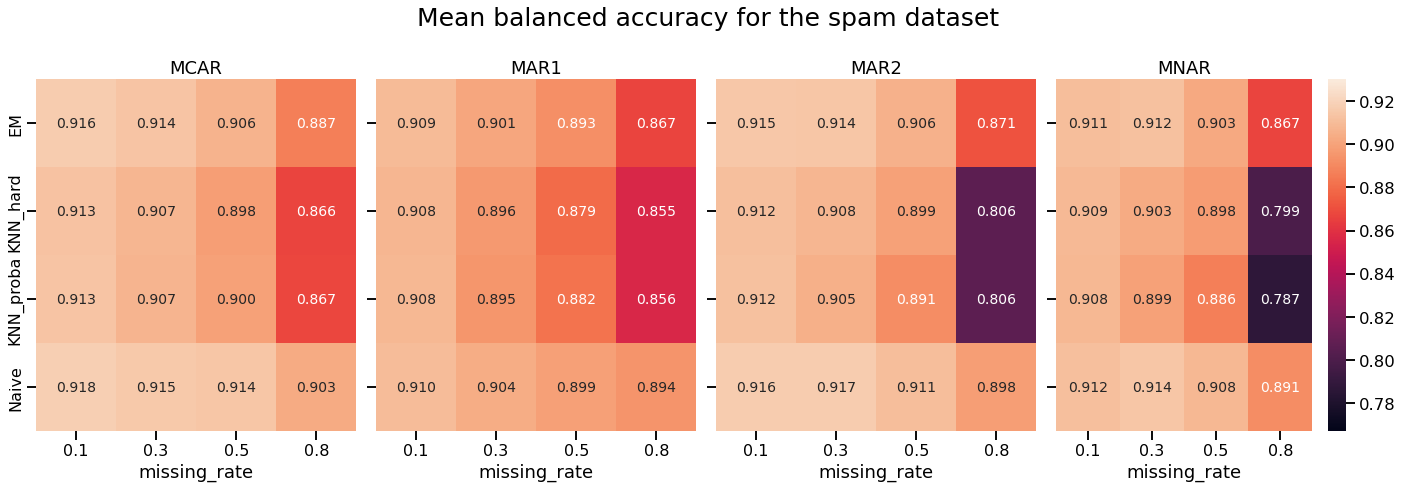

In [31]:
sns.set_context("talk", font_scale=1)
df_no_oracle = summary[summary["method"] != "Oracle"]

fig, axes = plt.subplots(1, 4, figsize=(20, 7))

missing_schemas = ['MCAR', 'MAR1', 'MAR2', 'MNAR']

vmin = spam["balanced_accuracy"].min()
vmax = spam["balanced_accuracy"].max()

for i, schema in enumerate(missing_schemas):
    d = spam[spam["missing_schema"] == schema]
    d = d[d["method"] != 'Oracle']
    heatmap_data = d.groupby(
        ["method", "missing_rate"]
    )["balanced_accuracy"].mean().unstack()

    sns.heatmap(
            heatmap_data,
            annot=True,
            fmt=".3f",
            annot_kws={"size": 14},
            vmin=vmin,
            vmax=vmax,
            cbar=(i == len(missing_schemas) - 1), 
            ax=axes[i]
    )

    axes[i].set_title(f"{schema}")
    axes[i].set_ylabel("")
    if i != 0:
        axes[i].set_yticklabels([])
            
    axes[i].tick_params(axis='both', labelsize=16)
        
fig.suptitle("Mean balanced accuracy for the spam dataset", fontsize=25)
plt.tight_layout()
plt.show()

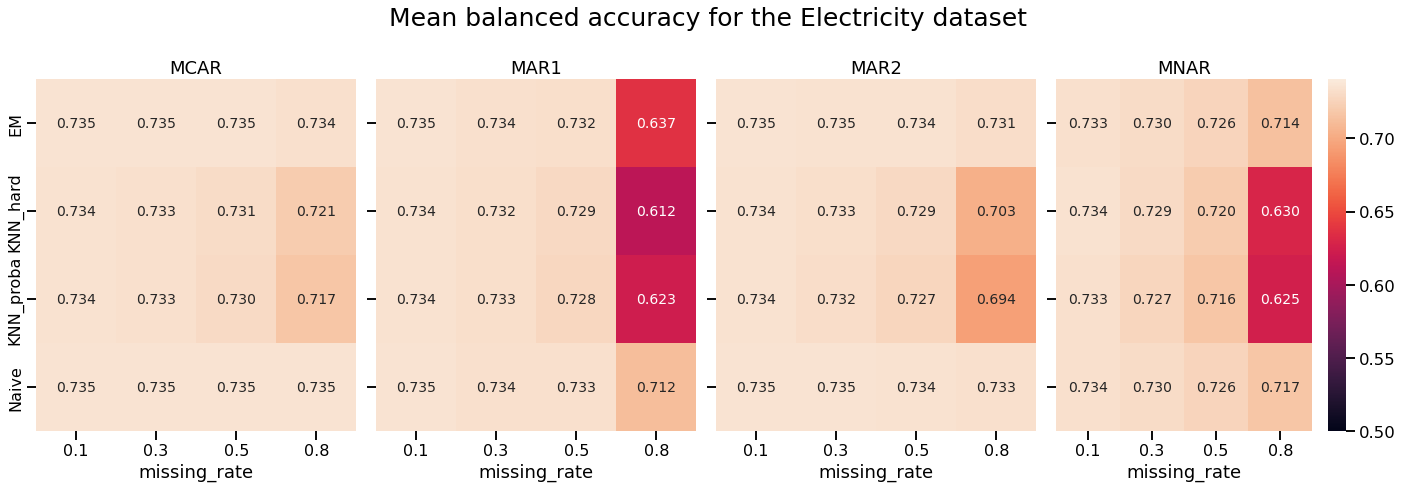

In [76]:
sns.set_context("talk", font_scale=1)

fig, axes = plt.subplots(1, 4, figsize=(20, 7))

missing_schemas = ['MCAR', 'MAR1', 'MAR2', 'MNAR']

vmin = elec["balanced_accuracy"].min()
vmax = elec["balanced_accuracy"].max()

for i, schema in enumerate(missing_schemas):
    d = elec[elec["missing_schema"] == schema]
    d = d[d["method"] != 'Oracle']
    heatmap_data = d.groupby(
        ["method", "missing_rate"]
    )["balanced_accuracy"].mean().unstack()

    sns.heatmap(
            heatmap_data,
            annot=True,
            fmt=".3f",
            annot_kws={"size": 14},
            vmin=vmin,
            vmax=vmax,
            cbar=(i == len(missing_schemas) - 1), 
            ax=axes[i]
    )

    axes[i].set_title(f"{schema}")
    axes[i].set_ylabel("")
    if i != 0:
        axes[i].set_yticklabels([])
            
    axes[i].tick_params(axis='both', labelsize=16)
        
fig.suptitle("Mean balanced accuracy for the Electricity dataset", fontsize=25)
plt.tight_layout()
plt.show()

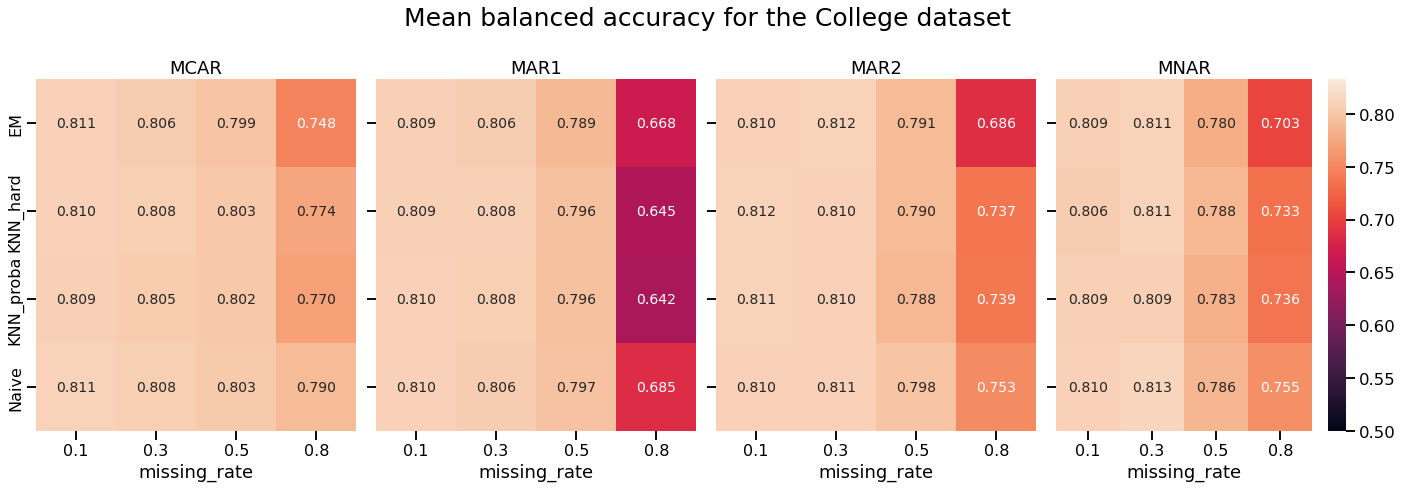

In [77]:
sns.set_context("talk", font_scale=1)
fig, axes = plt.subplots(1, 4, figsize=(20, 7))

missing_schemas = ['MCAR', 'MAR1', 'MAR2', 'MNAR']

vmin = college["balanced_accuracy"].min()
vmax = college["balanced_accuracy"].max()

for i, schema in enumerate(missing_schemas):
    d = college[college["missing_schema"] == schema]
    d = d[d["method"] != 'Oracle']
    heatmap_data = d.groupby(
        ["method", "missing_rate"]
    )["balanced_accuracy"].mean().unstack()

    sns.heatmap(
            heatmap_data,
            annot=True,
            fmt=".3f",
            annot_kws={"size": 14},
            vmin=vmin,
            vmax=vmax,
            cbar=(i == len(missing_schemas) - 1), 
            ax=axes[i]
    )

    axes[i].set_title(f"{schema}")
    axes[i].set_ylabel("")
    if i != 0:
        axes[i].set_yticklabels([])
            
    axes[i].tick_params(axis='both', labelsize=16)
        
fig.suptitle("Mean balanced accuracy for the College dataset", fontsize=25)
plt.tight_layout()
plt.show()

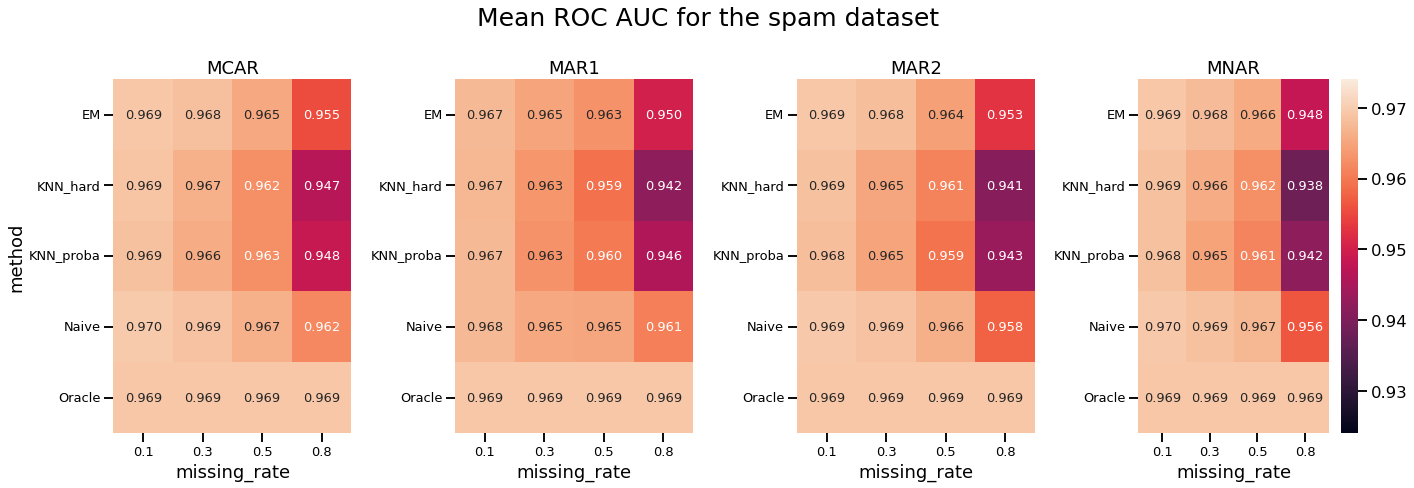

In [98]:
sns.set_context("talk", font_scale=1)

fig, axes = plt.subplots(1, 4, figsize=(20, 7))

vmin = spam["roc_auc"].min()
vmax = spam["roc_auc"].max()

for i, schema in enumerate(missing_schemas):
    d = spam[spam["missing_schema"] == schema]
    
    heatmap_data = d.groupby(
        ["method", "missing_rate"]
    )["roc_auc"].mean().unstack()
    
    sns.heatmap(
        heatmap_data,
        annot=True,
        fmt=".3f",
        annot_kws={"size": 13},
        vmin=vmin,
        vmax=vmax,
        cbar=(i == len(missing_schemas) - 1), 
        ax=axes[i]
    )
    
    axes[i].set_title(f"{schema}")
    if i != 0:
        axes[i].set_ylabel("")
    axes[i].tick_params(axis='both', labelsize=13)
fig.suptitle("Mean ROC AUC for the spam dataset", fontsize=25)
plt.tight_layout()
plt.show()

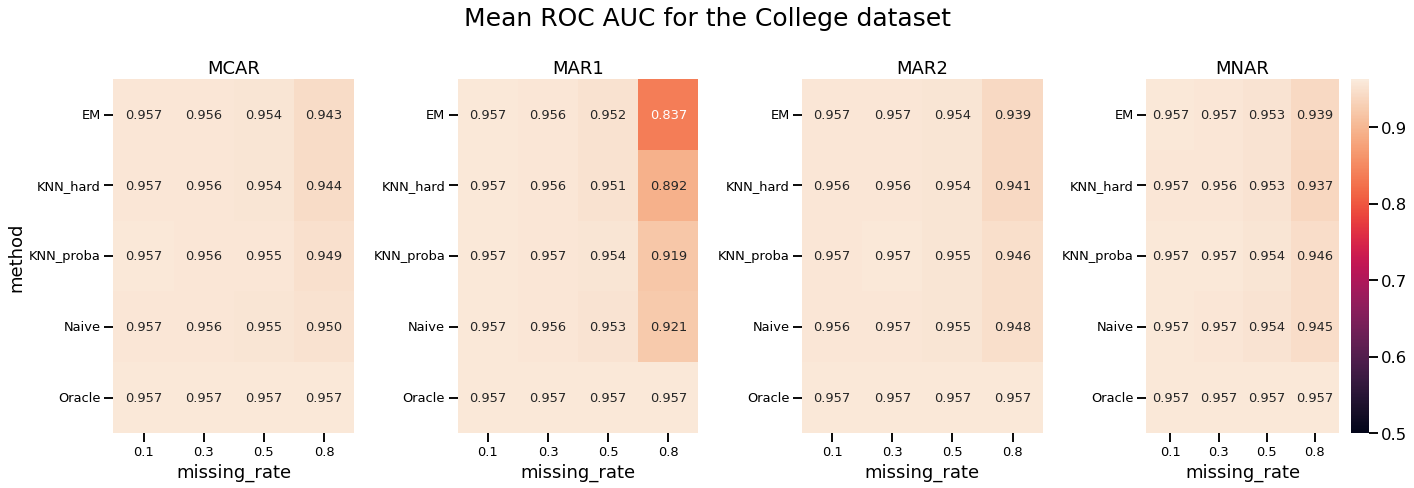

In [101]:
sns.set_context("talk", font_scale=1)

fig, axes = plt.subplots(1, 4, figsize=(20, 7))

vmin = college["roc_auc"].min()
vmax = college["roc_auc"].max()

for i, schema in enumerate(missing_schemas):
    d = college[college["missing_schema"] == schema]
    
    heatmap_data = d.groupby(
        ["method", "missing_rate"]
    )["roc_auc"].mean().unstack()
    
    sns.heatmap(
        heatmap_data,
        annot=True,
        fmt=".3f",
        annot_kws={"size": 13},
        vmin=vmin,
        vmax=vmax,
        cbar=(i == len(missing_schemas) - 1), 
        ax=axes[i]
    )
    
    axes[i].set_title(f"{schema}")
    if i != 0:
        axes[i].set_ylabel("")
    axes[i].tick_params(axis='both', labelsize=13)
fig.suptitle("Mean ROC AUC for the College dataset", fontsize=25)
plt.tight_layout()
plt.show()

### Best performing methods for each dataset and missing rate and schema

In [100]:
df_no_oracle = summary[summary["method"] != "Oracle"]
df_no_oracle = df_no_oracle[df_no_oracle["dataset"] != "Employee"]
agg = df_no_oracle.groupby(
    ["dataset", "missing_schema", "missing_rate", "method"]
)["balanced_accuracy"].mean().reset_index()

best = agg.loc[
    agg.groupby(
        ["dataset", "missing_schema", "missing_rate"]
    )["balanced_accuracy"].idxmax()
]

best["summary"] = (
    best["method"] + " (" + best["balanced_accuracy"].round(3).astype(str) + ")"
)

for dataset in best["dataset"].unique():
    sub = best[best["dataset"] == dataset]
    
    table = sub.pivot(
        index="missing_rate",
        columns="missing_schema",
        values="summary"
    )
    
    print(f"\n{dataset}")
    print(table)


College
missing_schema              MAR1              MAR2           MCAR  \
missing_rate                                                        
0.1             KNN_proba (0.81)  KNN_hard (0.812)  Naive (0.811)   
0.3             KNN_hard (0.808)        EM (0.812)  Naive (0.808)   
0.5                Naive (0.797)     Naive (0.798)  Naive (0.803)   
0.8                Naive (0.685)     Naive (0.753)   Naive (0.79)   

missing_schema              MNAR  
missing_rate                      
0.1                 Naive (0.81)  
0.3                Naive (0.813)  
0.5             KNN_hard (0.788)  
0.8                Naive (0.755)  

Electricity
missing_schema           MAR1           MAR2           MCAR              MNAR
missing_rate                                                                 
0.1                EM (0.735)  Naive (0.735)     EM (0.735)  KNN_hard (0.734)
0.3             Naive (0.734)  Naive (0.735)  Naive (0.735)         EM (0.73)
0.5             Naive (0.733)  Naive (0.7

### Performance degradation visualization

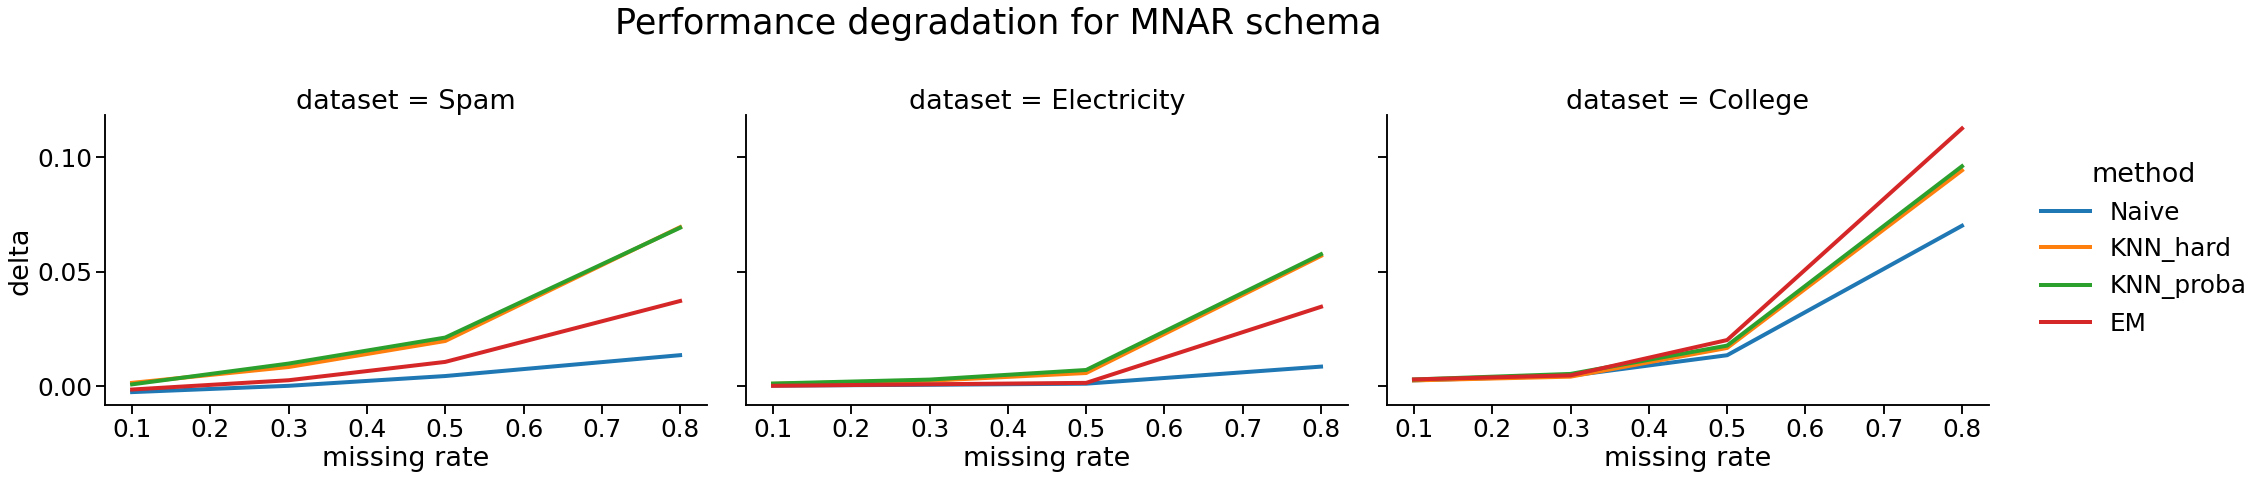

In [75]:
oracle = df[df["method"] == "Oracle"]

merged = df[df["method"] != "Oracle"].merge(
    oracle,
    on=["dataset", "missing_schema", "missing_rate"],
    suffixes=("", "_oracle")
)

merged = merged[merged["dataset"] != "Employee"]
merged = merged[merged["missing_schema"] != "MNAR"]

merged["delta"] = merged["balanced_accuracy_oracle"] - merged["balanced_accuracy"]

sns.set_context("talk", font_scale=1.5)

g = sns.FacetGrid(
    merged,
    col="dataset",
    hue="method",
    height=7,
    aspect=1.2
)

g.map(sns.lineplot, "missing_rate", "delta", ci=None, linewidth=4)

g.add_legend(bbox_to_anchor=(1, 0.5), loc='center left')

g.set_axis_labels("missing rate", "delta")

plt.suptitle("Performance degradation for MNAR schema", fontsize=35)
plt.tight_layout()
plt.show()

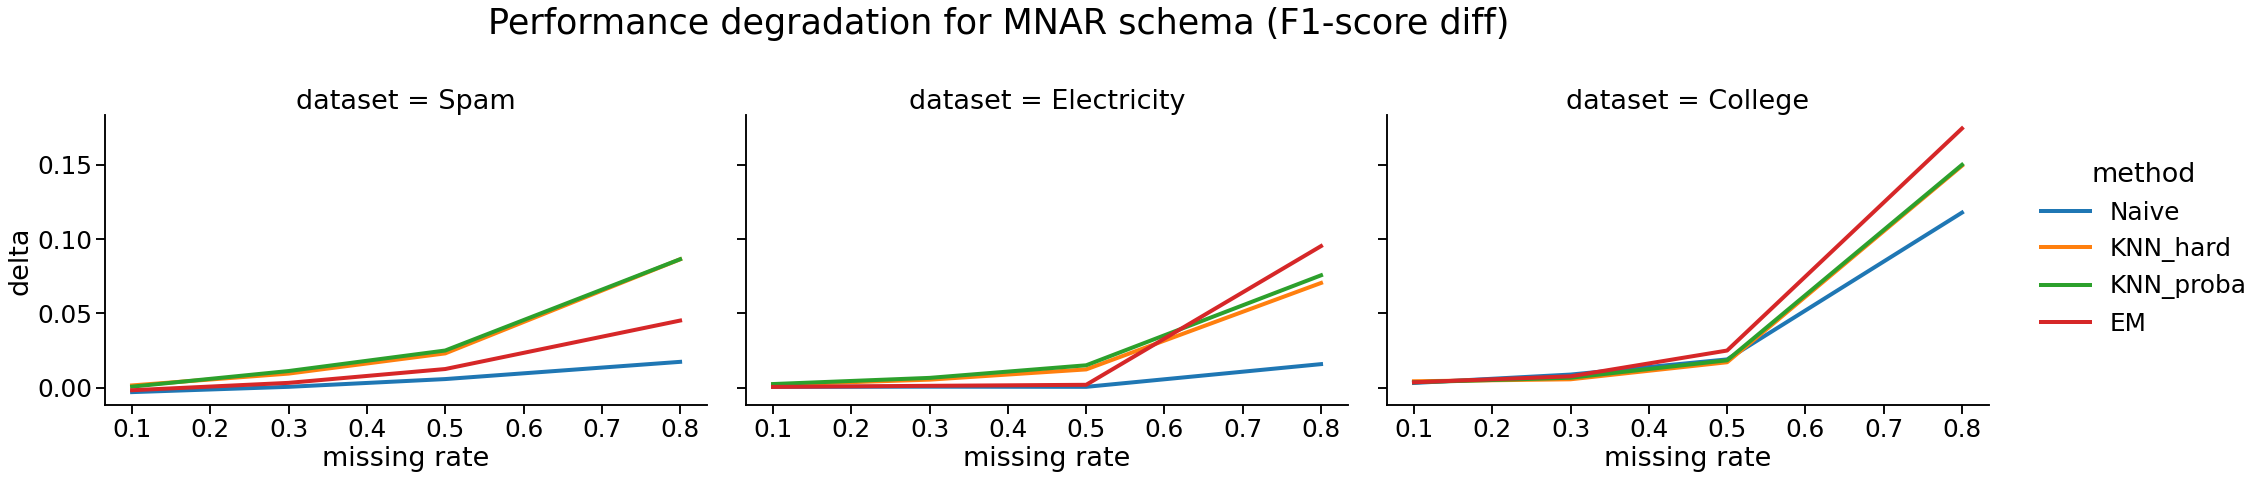

In [82]:
oracle = df[df["method"] == "Oracle"]

merged = df[df["method"] != "Oracle"].merge(
    oracle,
    on=["dataset", "missing_schema", "missing_rate"],
    suffixes=("", "_oracle")
)

merged = merged[merged["dataset"] != "Employee"]
merged = merged[merged["missing_schema"] != "MNAR"]

merged["delta"] = merged["f1_score_oracle"] - merged["f1_score"]

sns.set_context("talk", font_scale=1.5)

g = sns.FacetGrid(
    merged,
    col="dataset",
    hue="method",
    height=7,
    aspect=1.2
)

g.map(sns.lineplot, "missing_rate", "delta", ci=None, linewidth=4)

g.add_legend(bbox_to_anchor=(1, 0.5), loc='center left')

g.set_axis_labels("missing rate", "delta")

plt.suptitle("Performance degradation for MNAR schema (F1-score diff)", fontsize=35)
plt.tight_layout()
plt.show()

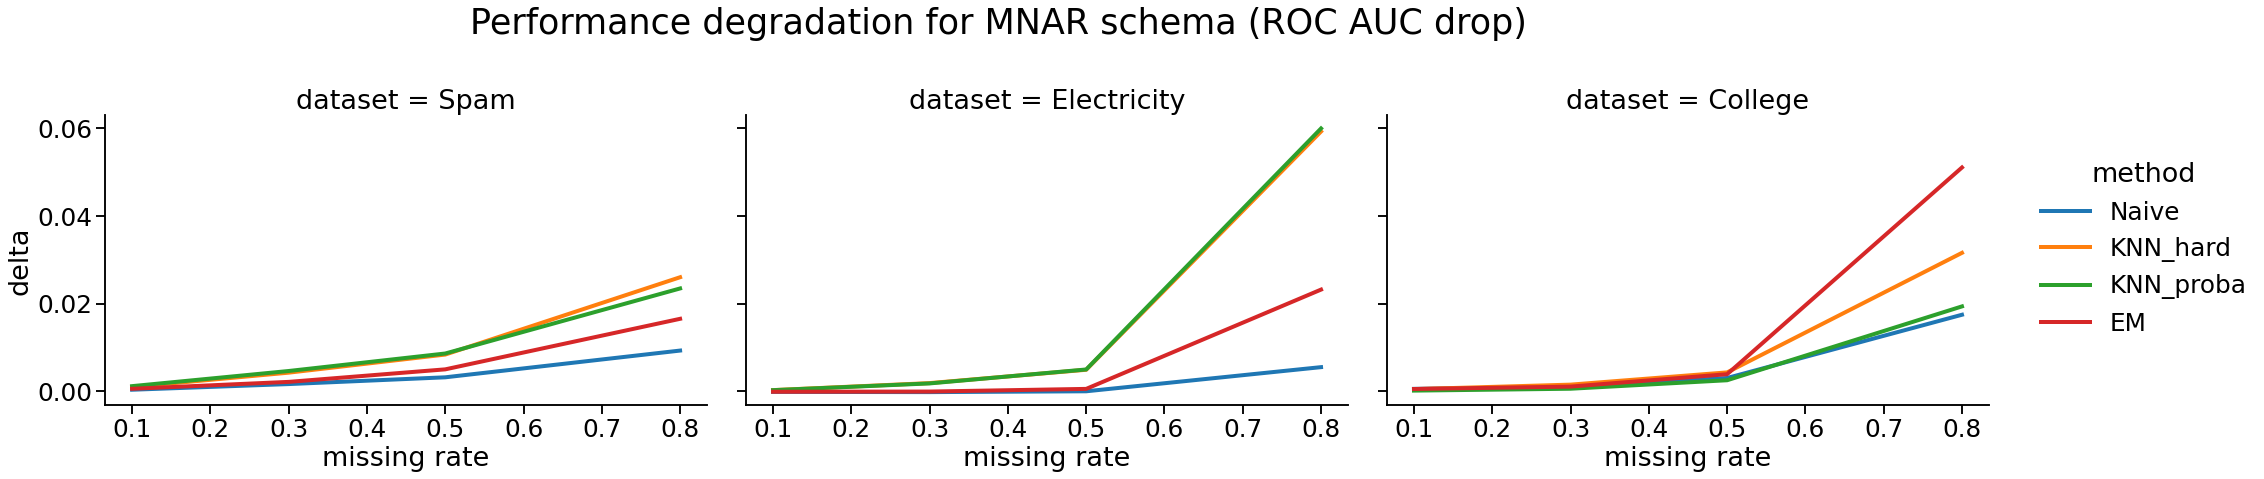

In [126]:
oracle = df[df["method"] == "Oracle"]

merged = df[df["method"] != "Oracle"].merge(
    oracle,
    on=["dataset", "missing_schema", "missing_rate"],
    suffixes=("", "_oracle")
)

merged = merged[merged["dataset"] != "Employee"]
merged = merged[merged["missing_schema"] != "MNAR"]

merged["delta"] = merged["roc_auc_oracle"] - merged["roc_auc"]

sns.set_context("talk", font_scale=1.5)

g = sns.FacetGrid(
    merged,
    col="dataset",
    hue="method",
    height=7,
    aspect=1.2
)

g.map(sns.lineplot, "missing_rate", "delta", ci=None, linewidth=4)

g.add_legend(bbox_to_anchor=(1, 0.5), loc='center left')

g.set_axis_labels("missing rate", "delta")

plt.suptitle("Performance degradation for MNAR schema (ROC AUC drop)", fontsize=35)
plt.tight_layout()
plt.show()

### Method stability and performance

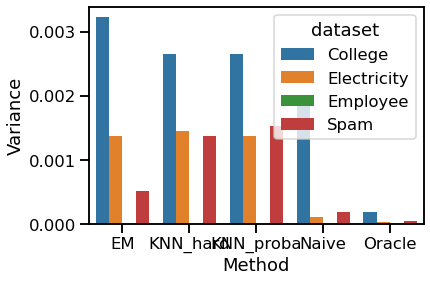

In [78]:
stability = df.groupby(
    ["dataset", "method"]
)["balanced_accuracy"].var().reset_index()

sns.barplot(
    data=stability,
    x="method",
    y="balanced_accuracy",
    hue="dataset"
)

plt.ylabel("Variance")
plt.xlabel("Method")
plt.show()

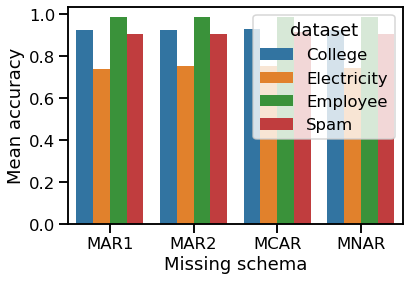

In [105]:
scheme_perf = df.groupby(
    ["dataset", "missing_schema"]
)["accuracy"].mean().reset_index()

sns.set_context("talk", font_scale=1)

sns.barplot(
    data=scheme_perf,
    x="missing_schema",
    y="accuracy",
    hue="dataset"
)

plt.ylabel("Mean accuracy")
plt.xlabel("Missing schema")
plt.show()